# 020 — Training

Train UNet, ResUNet, and Attention UNet on the RGB → IR translation task.
Checkpoints are saved to `models/{arch}/best_model.keras`.
Logs are written to `logs/{arch}/` for TensorBoard.

In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

In [2]:
import matplotlib.pyplot as plt
import tensorflow as tf

from scripts.config import settings
from scripts.dataset import build_dataset, grouped_train_val_test_split, load_image_pairs
from scripts.trainer import compile_model, get_callbacks, get_model
from scripts.visualization import plot_training_curves

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")
print(f"TensorFlow version: {tf.__version__}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.16.2


## 1. Build datasets

In [3]:
pairs = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
train_pairs, val_pairs, _ = grouped_train_val_test_split(
    pairs,
    train_ratio=settings.TRAIN_RATIO,
    val_ratio=settings.VAL_RATIO,
    seed=settings.SEED,
)

train_ds = build_dataset(
    train_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=True,
    shuffle=True,
    seed=settings.SEED,
)
val_ds = build_dataset(
    val_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=False,
    shuffle=False,
)

print(f"Train: {len(train_pairs)} patches ({len(train_ds)} batches)")
print(f"Val:   {len(val_pairs)} patches ({len(val_ds)} batches)")

2026-06-02 23:03:17.526561: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-06-02 23:03:17.526599: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-02 23:03:17.526610: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-06-02 23:03:17.526632: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-02 23:03:17.526651: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Train: 423 patches (53 batches)
Val:   110 patches (14 batches)


In [ ]:
arch = 'unet'
model = get_model(arch)
model = compile_model(
    model,
    lr=settings.LEARNING_RATE,
    loss_alpha=settings.LOSS_ALPHA,
)
model.summary(line_length=80)

## 2. Train all architectures

To run a quick smoke test, set `EPOCHS = 2` below.

In [ ]:
ARCHITECTURES = ["unet", "resunet", "attention_unet"]
EPOCHS = settings.EPOCHS  # Change to 2 for a smoke test

histories: dict = {}

for arch in ARCHITECTURES:
    print(f"\n{'='*60}")
    print(f"  Architecture: {arch}")
    print(f"{'='*60}")

    model = get_model(arch)
    model = compile_model(
        model,
        lr=settings.LEARNING_RATE,
        loss_alpha=settings.LOSS_ALPHA,
    )
    model.summary(line_length=80)

    callbacks = get_callbacks(
        arch,
        log_dir=settings.LOGS_DIR,
        model_dir=settings.MODELS_DIR,
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )
    histories[arch] = history.history

    best_val_loss = min(history.history["val_loss"])
    print(f"\nBest val_loss ({arch}): {best_val_loss:.4f}")


  Architecture: unet


Model: "unet"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer           │ (None, None,      │           0 │ -                  │
│ (InputLayer)          │ None, 3)          │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d (Conv2D)       │ (None, None,      │       1,728 │ input_layer[0][0]  │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization   │ (None, None,      │         256 │ conv2d[0][0]       │
│ (BatchNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu (ReLU)          │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_1 (Conv2D)     │ (None, None,      │      36,864 │ re_lu[0][0]        │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_1 │ (None, None,      │         256 │ conv2d_1[0][0]     │
│ (BatchNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_1 (ReLU)        │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ max_pooling2d         │ (None, None,      │           0 │ re_lu_1[0][0]      │
│ (MaxPooling2D)        │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_2 (Conv2D)     │ (None, None,      │      73,728 │ max_pooling2d[0][… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_2 │ (None, None,      │         512 │ conv2d_2[0][0]     │
│ (BatchNormalization)  │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_2 (ReLU)        │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_3 (Conv2D)     │ (None, None,      │     147,456 │ re_lu_2[0][0]      │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_3 │ (None, None,      │         512 │ conv2d_3[0][0]     │
│ (BatchNormalization)  │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_3 (ReLU)        │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ max_pooling2d_1       │ (None, None,      │           0 │ re_lu_3[0][0]      │
│ (MaxPooling2D)        │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_4 (Conv2D)     │ (None, None,      │     294,912 │ max_pooling2d_1[0… │
│                       │ None,

 Total params: 31,049,409 (118.44 MB)

 Trainable params: 31,037,633 (118.40 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2         │ (None, None,      │           0 │ -                  │
│ (InputLayer)          │ None, 3)          │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_47 (Conv2D)    │ (None, None,      │       1,728 │ input_layer_2[0][… │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_… │ (None, None,      │         256 │ conv2d_47[0][0]    │
│ (BatchNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_36 (ReLU)       │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_48 (Conv2D)    │ (None, None,      │      36,864 │ re_lu_36[0][0]     │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_… │ (None, None,      │         256 │ conv2d_48[0][0]    │
│ (BatchNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_37 (ReLU)       │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ max_pooling2d_8       │ (None, None,      │           0 │ re_lu_37[0][0]     │
│ (MaxPooling2D)        │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_49 (Conv2D)    │ (None, None,      │      73,728 │ max_pooling2d_8[0… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_… │ (None, None,      │         512 │ conv2d_49[0][0]    │
│ (BatchNormalization)  │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_38 (ReLU)       │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_50 (Conv2D)    │ (None, None,      │     147,456 │ re_lu_38[0][0]     │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_… │ (None, None,      │         512 │ conv2d_50[0][0]    │
│ (BatchNormalization)  │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_39 (ReLU)       │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ max_pooling2d_9       │ (None, None,      │           0 │ re_lu_39[0][0]     │
│ (MaxPooling2D)        │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_51 (Conv2D)    │ (None, None,      │     294,912 │ max_pooling2d_9[0… │
│                       │ None,

 Total params: 31,398,049 (119.77 MB)

 Trainable params: 31,386,273 (119.73 MB)

 Non-trainable params: 11,776 (46.00 KB)

Epoch 1/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 0.3004 - mae: 0.1526 - psnr: 16.1159 - ssim: 0.3546
Epoch 1: val_loss improved from None to 0.27180, saving model to /Users/marcomanduca/Desktop/projects/deep_layers/models/attention_unet/best_model.keras

Epoch 1: finished saving model to /Users/marcomanduca/Desktop/projects/deep_layers/models/attention_unet/best_model.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 175s 3s/step - loss: 0.2418 - mae: 0.1222 - psnr: 17.9867 - ssim: 0.4793 - val_loss: 0.2718 - val_mae: 0.2100 - val_psnr: 13.2914 - val_ssim: 0.5841 - learning_rate: 1.0000e-04
Epoch 2/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 0.1983 - mae: 0.1077 - psnr: 19.0884 - ssim: 0.5903
Epoch 2: val_loss improved from 0.27180 to 0.26626, saving model to /Users/marcomanduca/Desktop/projects/deep_layers/models/attention_unet/best_model.keras

Epoch 2: finished saving model to /Users/marcomanduca/Desktop/projects/deep_layers/models/attention_unet/best_model.keras
53/53 ━━━━━━━━━━━━━━━━━━━

## 3. Training curves

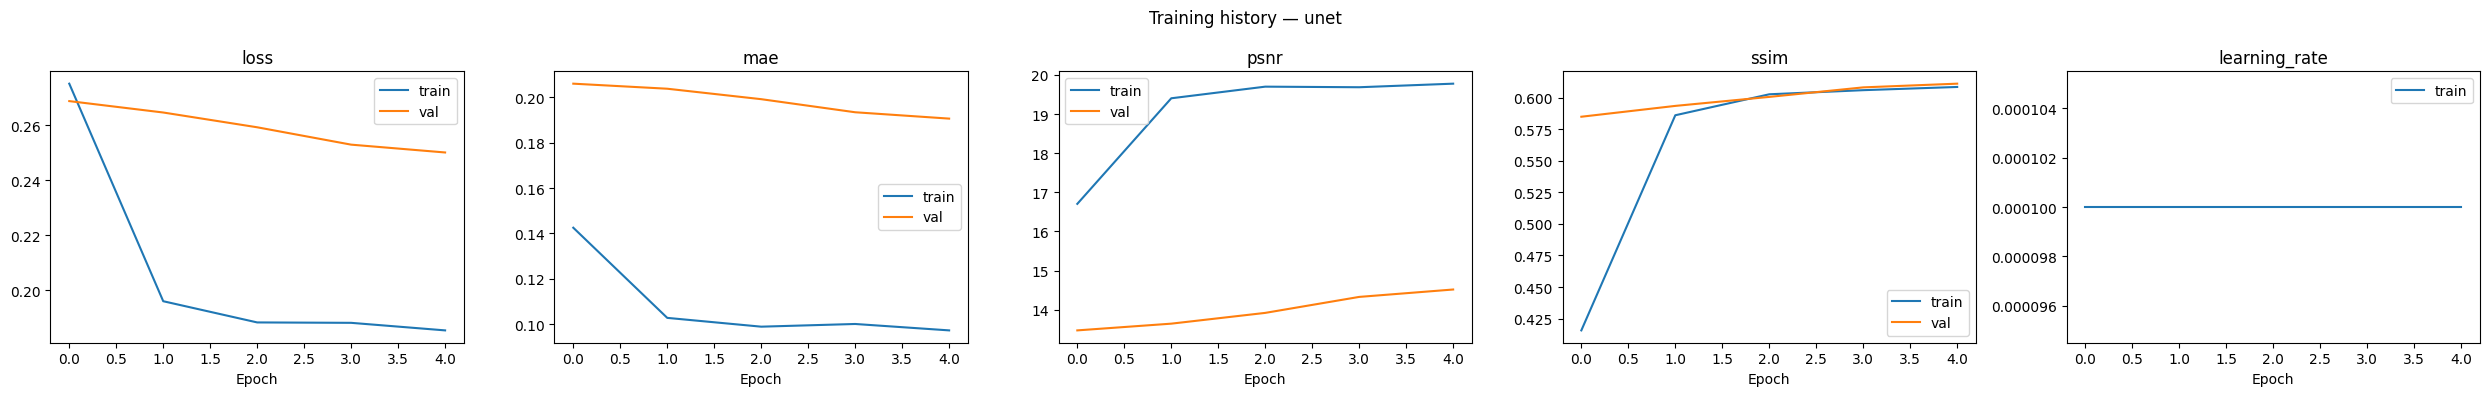

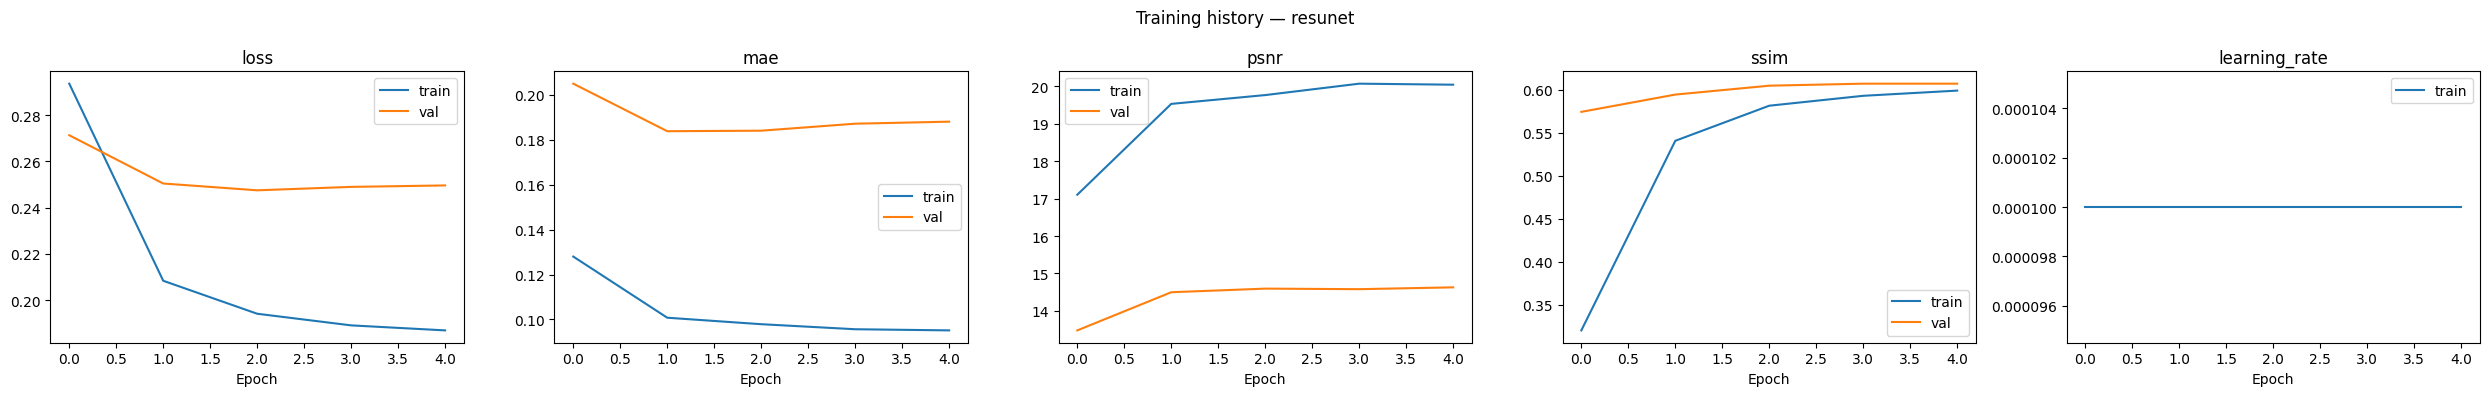

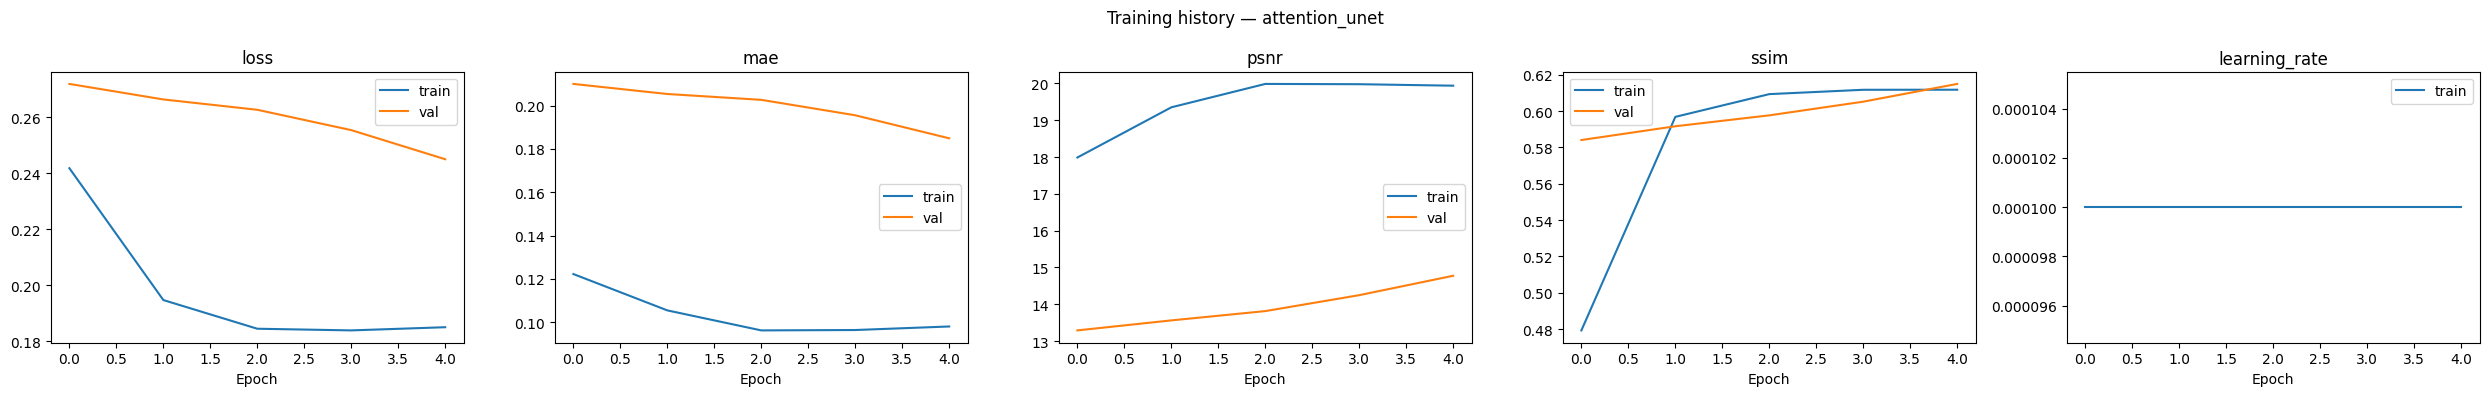

In [5]:
for arch, history in histories.items():
    fig = plot_training_curves(history, title=f"Training history — {arch}")
    plt.show()

## 4. Summary

Checkpoints saved to `models/{arch}/best_model.keras`.  
Run `tensorboard --logdir logs/` to inspect curves interactively.

In [6]:
for arch in ARCHITECTURES:
    ckpt = settings.MODELS_DIR / arch / "best_model.keras"
    status = "found" if ckpt.exists() else "MISSING"
    print(f"{arch:<20}: {status}  ({ckpt})")

unet                : found  (/Users/marcomanduca/Desktop/projects/deep_layers/models/unet/best_model.keras)
resunet             : found  (/Users/marcomanduca/Desktop/projects/deep_layers/models/resunet/best_model.keras)
attention_unet      : found  (/Users/marcomanduca/Desktop/projects/deep_layers/models/attention_unet/best_model.keras)
